# preprocessing for cell interaction

In [1]:
# load packages
import h5py
import scipy.sparse as scs
import pandas as pd
import anndata as ad
import os
import glob
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import median_abs_deviation
import scanpy as sc
import random
import hisepy as hp

In [2]:
# download data
hp.cache_files(['89859cec-8d36-47fd-a165-f0f34ae90284','6de3ba28-d25e-43e5-a221-b9ac0acf91d3', '609f7543-d4d5-41e9-a3d2-8e50c3e7c61d'])

['/home/workspace/input/569004694/UCSDCU_Y4/89859cec-8d36-47fd-a165-f0f34ae90284/ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad',
 '/home/workspace/input/569004694/UCSDCU_Y4/6de3ba28-d25e-43e5-a221-b9ac0acf91d3/ALTRA_scRNA_Non_Naive_CD4_Tcells_clean_obj.h5ad',
 '/home/workspace/input/569004694/UCSDCU_Y4/609f7543-d4d5-41e9-a3d2-8e50c3e7c61d/ALTRA_certPro_scRNA_141_samples_combined_adata.h5ad']

In [3]:
# load the deep clean data for all cells in 141 samples
# use backend to preseve memory
combine_adata = sc.read_h5ad(
   '/home/workspace/input/569004694/UCSDCU_Y4/609f7543-d4d5-41e9-a3d2-8e50c3e7c61d/ALTRA_certPro_scRNA_141_samples_combined_adata.h5ad',
    backed='r'
)

/home/workspace/environment/minimal/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
# load the deep clean data for T memory
# use backend to preseve memory
cd4mem_adata = sc.read_h5ad(
    '/home/workspace/input/569004694/UCSDCU_Y4/6de3ba28-d25e-43e5-a221-b9ac0acf91d3/ALTRA_scRNA_Non_Naive_CD4_Tcells_clean_obj.h5ad',
    backed='r'
)

In [5]:
cluster_counts = cd4mem_adata.obs.groupby(['AIFI_L3', 'leiden_NMF_0.4_v1']).size().reset_index()
cluster_counts.loc[cluster_counts['AIFI_L3']=='CD4 MAIT']

/tmp/ipykernel_1156/2914488156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_counts = cd4mem_adata.obs.groupby(['AIFI_L3', 'leiden_NMF_0.4_v1']).size().reset_index()


,AIFI_L3,leiden_NMF_0.4_v1,0
0,CD4 MAIT,0,30
1,CD4 MAIT,1,1359
2,CD4 MAIT,2,134
3,CD4 MAIT,3,0
4,CD4 MAIT,4,1
5,CD4 MAIT,5,0
6,CD4 MAIT,6,0
7,CD4 MAIT,7,0
8,CD4 MAIT,8,0
9,CD4 MAIT,9,0


In [6]:
# load the B mem data
Bmem_adata = sc.read_h5ad(
    '/home/workspace/input/569004694/UCSDCU_Y4/89859cec-8d36-47fd-a165-f0f34ae90284/ALTRA_scRNA_Bmem_cells_filtered_certPro.h5ad',
    backed='r'
)

In [7]:
# load metadata for aim3 study and isolated B and t cells from aim3
aim3_meta = pd.read_csv('/home/workspace/github/ra-longitudinal/metadata/ALTRA_RA_Aim3_ALTRA_converters_longitudinal_scrna_metadata.csv')

In [8]:
# subset the T and B cells data in AIM3
aim3_tb_adata = combine_adata[((combine_adata.obs['barcodes'].isin(cd4mem_adata.obs['barcodes'])) | 
                               (combine_adata.obs['barcodes'].isin(Bmem_adata.obs['barcodes']))) & 
    (combine_adata.obs['sample.sampleKitGuid'].isin(aim3_meta['sample.sampleKitGuid']))].to_memory()

In [9]:
aim3_tb_adata

AnnData object with n_obs × n_vars = 247306 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'St

In [10]:
aim3_tb_adata.obs['sample.sampleKitGuid'].unique()

['KT00219', 'KT00453', 'KT02817', 'KT02856', 'KT00478', ..., 'KT00480', 'KT00052', 'KT02135', 'KT00109', 'KT02948']
Length: 65
Categories (65, object): ['KT00052', 'KT00056', 'KT00057', 'KT00064', ..., 'KT04108', 'KT04462', 'KT04474', 'KT04924']

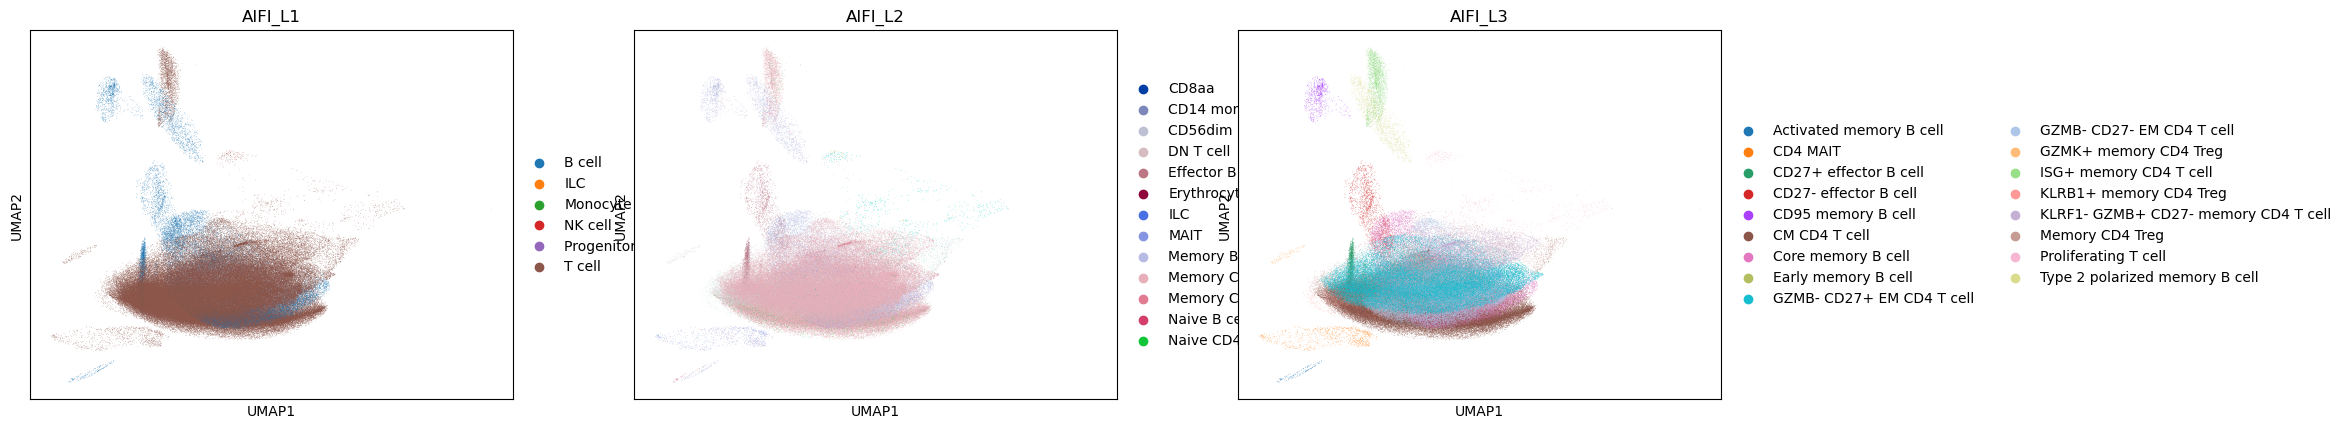

In [11]:
sc.pl.umap(
    aim3_tb_adata, #legend_loc='on data',
    color=['AIFI_L1', 'AIFI_L2', 'AIFI_L3']
)

In [13]:
cd4mem_adata.obs.reset_index(names='index')[['barcodes', 'leiden_NMF_0.4_v1']]

,barcodes,leiden_NMF_0.4_v1
0,c68ffbec42fe11ecbc8902dee9a94afb,3
1,c6915a2842fe11ecbc8902dee9a94afb,6
2,c691873242fe11ecbc8902dee9a94afb,12
3,781386e469f511ee9378c2fb727395d0,7
4,78134d8c69f511ee9378c2fb727395d0,11
...,...,...
460539,1761f5622bcd11eeb37d726474e7f82b,13
460540,175d0b922bcd11eeb37d726474e7f82b,13
460541,84893604c0a511eba8817233ea04b219,13
460542,c6ab631048bd11eab2ee7a6edf799b61,13


In [14]:
# add cell type labels 
aim3_tb_adata.obs = aim3_tb_adata.obs.merge(cd4mem_adata.obs.reset_index(names='index')[['barcodes', 'leiden_NMF_0.4_v1']], how='left', on='barcodes')
aim3_tb_adata.obs = aim3_tb_adata.obs.merge(Bmem_adata.obs[['barcodes', 'leiden_0_8_anno']], how='left', on='barcodes')

In [15]:
aim3_tb_adata.obs

,barcodes,batch_id,cell_name,cell_uuid,chip_id,hto_barcode,hto_category,n_genes,n_mito_umis,n_reads,...,anti_ccp3_finalCombined,days_to_conversion,BMI,CMV_Status_Subj,age_conv,bmi_conv,file.batchID,status,leiden_NMF_0.4_v1,leiden_0_8_anno
0,b5aa7f4c120211eb859a46b4e30ed972,B026,fungiform_punctual_ram,b5aa7f4c120211eb859a46b4e30ed972,B026-P2C2,TGTCTTTCCTGCCAG,singlet,2478,282,25517,...,91.0,-498.0,23.699600,Negative,58.0,25.648918,B026,at_risk,NaN,CD27+ effector B cell
1,456f1d76428711ecbe4f8ede1e1ebd6b,B087,dubnium_weakminded_termite,456f1d76428711ecbe4f8ede1e1ebd6b,B087-P2C3,CTCCTCTGCAATTAC,singlet,1823,208,29279,...,56.0,-552.0,40.538375,Positive,46.0,42.650542,B087,at_risk,NaN,CD27+ effector B cell
2,9a265f28429b11ec88d2562c7340d3f2,B087,spiky_calceiform_nightjar,9a265f28429b11ec88d2562c7340d3f2,B087-P2C2,CTCCTCTGCAATTAC,singlet,1424,411,23964,...,56.0,-552.0,40.538375,Positive,46.0,42.650542,B087,at_risk,NaN,CD27+ effector B cell
3,8dc0a0ea120411eb8283deddafb7b651,B026,calm_bigoted_saiga,8dc0a0ea120411eb8283deddafb7b651,B026-P2C2,TGTCTTTCCTGCCAG,singlet,1194,281,9789,...,91.0,-498.0,23.699600,Negative,58.0,25.648918,B026,at_risk,NaN,CD27+ effector B cell
4,65f1550a99c911eeabca56e604b34ea0,B109,able_bilingual_queenbee,65f1550a99c911eeabca56e604b34ea0,B109-P2C3,TGATGGCCTATTGGG,singlet,2366,339,31147,...,219.0,-401.0,24.469640,Negative,62.0,24.550265,B109,at_risk,NaN,CD27+ effector B cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247301,1761a5c62bcd11eeb37d726474e7f82b,B159,baffling_imprecise_marmoset,1761a5c62bcd11eeb37d726474e7f82b,B159-P2C2,CTGTATGTCCGATTG,singlet,1464,197,13102,...,39.0,0.0,42.650542,Positive,46.0,42.650542,B159,conversion,13,NaN
247302,1761f5622bcd11eeb37d726474e7f82b,B159,appetitive_optimal_andeancat,1761f5622bcd11eeb37d726474e7f82b,B159-P2C2,CTGTATGTCCGATTG,singlet,1772,103,16285,...,39.0,0.0,42.650542,Positive,46.0,42.650542,B159,conversion,13,NaN
247303,175d0b922bcd11eeb37d726474e7f82b,B159,brassbound_beamlike_condor,175d0b922bcd11eeb37d726474e7f82b,B159-P2C2,CTGTATGTCCGATTG,singlet,1131,116,10631,...,39.0,0.0,42.650542,Positive,46.0,42.650542,B159,conversion,13,NaN
247304,84893604c0a511eba8817233ea04b219,B070,concise_durational_carp,84893604c0a511eba8817233ea04b219,B070-P2C3,AAGTATCGTTTCGCA,singlet,1664,177,18443,...,133.0,-204.0,25.931017,Positive,32.0,26.024996,B070,at_risk,13,NaN


In [16]:
# combine cell type labels
aim3_tb_adata.obs['cell_labels'] = aim3_tb_adata.obs['leiden_NMF_0.4_v1'].astype('string')
aim3_tb_adata.obs.loc[~aim3_tb_adata.obs['cell_labels'].isna(), 'cell_labels'] = 'CD4mem_C' + aim3_tb_adata.obs.loc[~aim3_tb_adata.obs['cell_labels'].isna(), 'cell_labels']
aim3_tb_adata.obs['cell_labels'] = aim3_tb_adata.obs['cell_labels'].fillna(aim3_tb_adata.obs['leiden_0_8_anno'].astype('string'))

In [17]:
aim3_tb_adata.obs['cell_labels'].unique().tolist()

['CD27+ effector B cell',
 'CD4mem_C11',
 'CD4mem_C7',
 'CD4mem_C5',
 'CD4mem_C10',
 'CD4mem_C3',
 'CD4mem_C12',
 'CD4mem_C9',
 'CD4mem_C6',
 'CD4mem_C14',
 'CD4mem_C15',
 'CD4mem_C8',
 'CD4mem_C16',
 'CD4mem_C18',
 'CD4mem_C0',
 'CD4mem_C4',
 'CD4mem_C1',
 'CD4mem_C17',
 'CD4mem_C2',
 'CD4mem_C13',
 'CD27- effector B cell',
 'CD27- effector B cell_C8',
 'CD27- effector B cell_C9',
 'Early memory B cell',
 'Core memory B cell',
 'Activated memory B cell',
 'CD95 memory B cell',
 'Type 2 polarized memory B cell']

In [18]:
aim3_tb_adata.write_h5ad('/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/ALTRA_aim3_T_B_mem_cells.h5ad')